In [2]:
import numpy as np 
import matplotlib.pyplot as plt

plt.style.use("dark")

In [17]:
from pyeeg.simulate import dummy_trf_kernel, simulate_pulse_inputs, simulate_smooth_input, simulate_trf_output
from pyeeg.models import TRFEstimator
from pyeeg.solvers import create_quadratic_regularizer
from pyeeg.utils import lag_matrix, lag_span

In [4]:
noise_ammount = 0.1

tker, ker1 = dummy_trf_kernel()
_, ker2 = dummy_trf_kernel(kernel_type='bipolar')
# Normalise
for k in [ker1, ker2]:
    k /= np.sqrt(sum(k**2))

t, pulses = simulate_pulse_inputs()
_, smooth = simulate_smooth_input(dur=30.)
x = np.c_[pulses, smooth]
y = simulate_trf_output(tker, ker1, pulses) + simulate_trf_output(tker, ker2, smooth)
y += np.random.randn(*y.shape) * noise_ammount

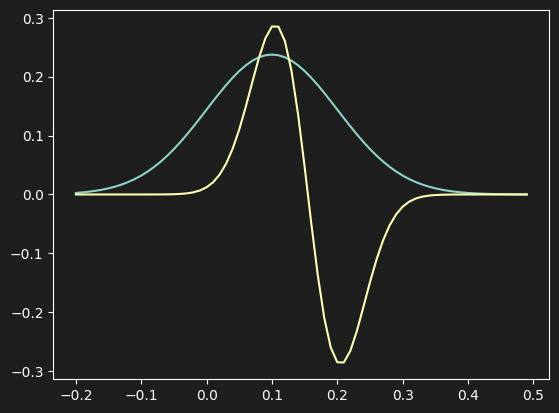

In [5]:
plt.plot(tker, np.c_[ker1, ker2])

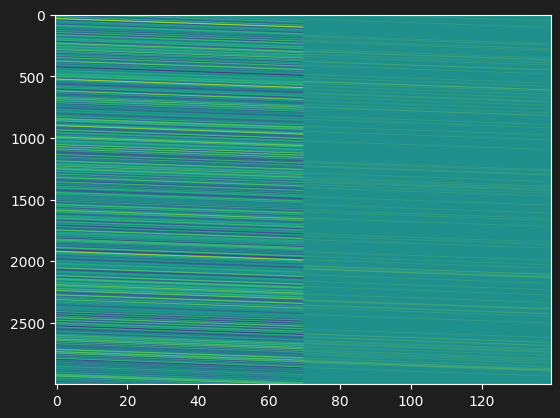

In [170]:
X2 = lag_matrix(np.c_[smooth, pulses], lag_span(-0.2, 0.5, 100), block_order='features')
plt.imshow(X2, aspect='auto')

In [142]:
fit_intercept = False
n_lags = len(trf.lags)

In [530]:
M = create_quadratic_regularizer(reg_type='smoothness', n_lags=len(trf.lags) )
# Boundaries
# M[0, 0] = 1
M[-1, -1] = 1
MM = block_diag(M, M)
# order
order = 0
for k in range(order):
    MM = MM.T@MM

In [531]:
MM

array([[ 2., -1.,  0., ...,  0.,  0.,  0.],
       [-1.,  2., -1., ...,  0.,  0.,  0.],
       [ 0., -1.,  2., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  2., -1.,  0.],
       [ 0.,  0.,  0., ..., -1.,  2., -1.],
       [ 0.,  0.,  0., ...,  0., -1.,  1.]], shape=(140, 140))

M is the classic smoothing laplacian matrix. However by computing $M^TM$, I get a sort of 2nd order derivative (not 2nd derivative, but 2nd order in approximation numerically I think) which greatly improve the smoothness AND seem to work relatively well on both pulse or smooth input without fine tuning alpha (banded ridge).

At least the advantage is in that this does NOT shrink only the coefficients to penalise by L2 norm, it only act on smoothness and the global energy in coefficient should remain the same. Thus on noise poluted TRF from pulse like input, instead of shrinking to zero by scale, it'll actually smooth out the TRF for potentially a much stronger reconstruction instead of just fighting SNR.

In [199]:
from scipy.linalg import cholesky

In [532]:
L = cholesky(MM)

In [299]:
alpha = 100
alpha1, alpha2 = 100, 10
# Banded Ridge
alpha = block_diag(np.diag(alpha1 * np.ones((70, ))), np.diag(alpha2 * np.ones((70,))))
X = X2
beta_0 = np.linalg.inv(X.T@X) @ (X.T@y) # UNREG
beta = np.linalg.inv(X.T@X + alpha@MM) @ (X.T@y)
# beta2 = np.linalg.inv(X.T@X + alpha@(L.T@L)) @ (X.T@y)
# I = np.eye(X.shape[1])
beta2 = np.linalg.inv(X.T@X + alpha*I) @ (X.T@y)

### Crazy feature!!!

I can create a regularised version from the unregularised DIRECTLY, as one mapping...

See [Wiki page](https://en.wikipedia.org/wiki/Ridge_regression#Application_to_existing_fit_results).

So simply by creating a mapping matrix:

$$
B = (X^TX + L^TL)^{-1}X^TX
$$

Then $x = Bx_0$ when $x_0$ was the unregularised solution is the regularised solution.

In [367]:
reg_apply = lambda G, beta: (np.linalg.inv(X.T@X + G.T@G)@(X.T@X)) @ beta

beta = reg_apply(8*L, beta_0)
%time beta = reg_apply(10*np.eye(140), beta_0)

CPU times: user 51.3 ms, sys: 4 μs, total: 51.3 ms
Wall time: 5.55 ms


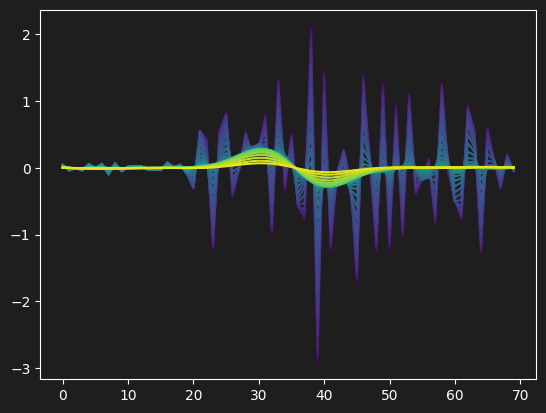

In [350]:
n_lines = 30
alphas = np.logspace(-2, 2, n_lines)
for k, alpha in enumerate(alphas):
    beta = reg_apply(alpha*np.eye(140), beta_0)
    # beta = reg_apply(alpha*L, beta_0)
    plt.plot(beta[:70], color=plt.cm.viridis(k/n_lines))
# plt.plot(beta_0[:70])

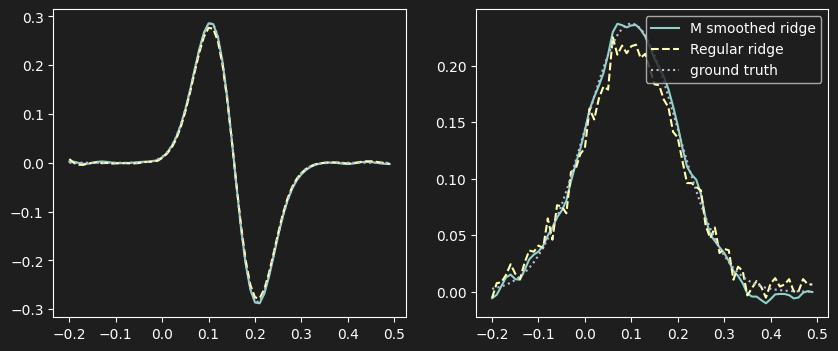

In [298]:
f, ax = plt.subplots(1, 2, sharex=True, figsize=(10, 4))

ax[0].plot(tker, beta[:70][int(fit_intercept):], label='M smoothed ridge')
ax[0].plot(tker, beta2[:70][int(fit_intercept):], label='L cholesky ridge', ls='--')
ax[0].plot(tker, ker2, label='ground truth', ls=':')
ax[1].plot(tker, beta[70:][int(fit_intercept):], label='M smoothed ridge')
ax[1].plot(tker, beta2[70:][int(fit_intercept):], label='Regular ridge', ls='--')
ax[1].plot(tker, ker1, label='ground truth', ls=':')
# plt.plot(tker, (beta-beta2)[int(fit_intercept):])
plt.legend()

### Other feat

The thikonov regularisation reuduces to a classic OLS with augmented matrices $X -> [X \quad L]$ and $Y -> [ Y \quad 0 ]$

See [wikipedia](https://en.wikipedia.org/wiki/Ridge_regression#Tikhonov_regularization_for_linear_equations)

In [533]:
Xext = np.r_[X, 100*L]
# Xext = np.r_[X, 10*np.eye(140)]
Yext = np.r_[y, np.zeros((len(L),))]

CPU times: user 288 ms, sys: 3.68 ms, total: 292 ms
Wall time: 25.6 ms


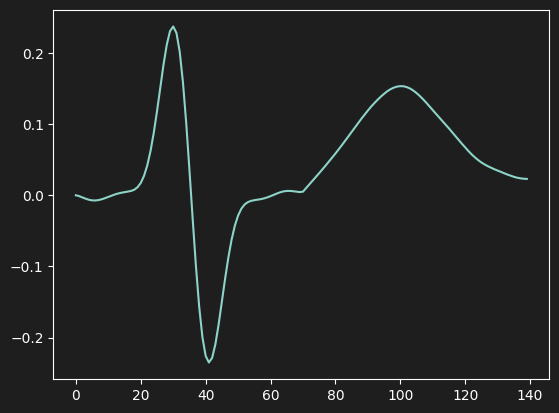

In [534]:
%time beta_ = np.linalg.inv(Xext.T@Xext) @ (Xext.T @ Yext)

plt.plot(beta_)

## Mapping into USV decomposition, with any L tikhonov

$$
\hat{x} = V Q D Q^T V^T A^T b
$$

where:

- ( D ) is diagonal with entries ( $D_{ii} = \frac{\sigma_i}{\sigma_i^2 + \alpha^2 \lambda_i}$ ),
- ( $\lambda_i$ ) are the eigenvalues of $V^T L^T L V$.

And

$$
V^T L^T L V = Q \Lambda Q^T
$$

In [412]:
from scipy.linalg import svd, eigh, eig

In [535]:
# Let's test that
U, s, Vt = svd(X, full_matrices=False)
L = cholesky(MM)
# L = np.eye(L.shape[0])
lamb, Q = eigh(Vt@(L.T@L)@Vt.T)
lamb = lamb[::-1]
Q = Q[:, ::-1]
# Q = Q.T
D = np.diag(s/(s**2+0.01**2*lamb))
# X = X - X.mean(0)
# beta_usv = Vt.T @ Q @ D @ Q.T @ Vt @ X.T @ y
beta_usv = Vt.T @ Q @ D @ Q.T @ Vt @ (X - X.mean(0)).T @ (y - y.mean())

In [555]:
# Let's test that
U, s, Vt = svd(X.T@X)
L = cholesky(MM)
# L = np.eye(L.shape[0])
lamb, Q = eigh(Vt@(MM)@Vt.T)
# lamb, Q = eigh(Vt@(np.eye(MM.shape[0]))@Vt.T)
lamb = lamb[::-1]
Q = Q[:, ::-1]
D = np.diag(1/(s+0.000001*lamb))
beta_usv = Vt.T @ (Q @ D @ Q.T) @ Vt @ X.T @ y

In [539]:
U, s, Vt = svd(X, full_matrices=False)
D = np.diag(s/(s**2+10**2))
beta_usv = Vt.T@D@ U.T@y

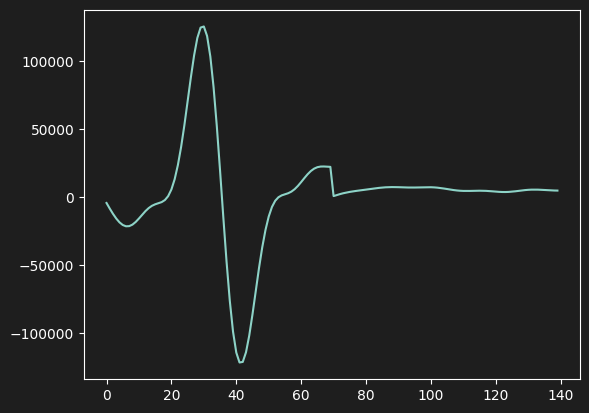

In [556]:
plt.plot(beta_usv)

In [423]:
trf = TRFEstimator(tmin=-0.2, tmax=0.5, srate=100, alpha=alpha, quadratic_reg=MM, fit_intercept=False)
trf.fit(x, y[:, None], feat_names=['pulses', 'smooth'])
trf.plot();

INFO:pyeeg:Lagging matrix...
INFO:pyeeg:Computing coefficients..


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2931 is different from 140)

In [118]:
from scipy.linalg import block_diag

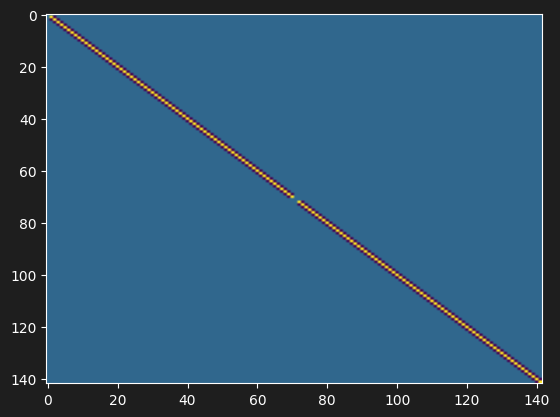

In [119]:
plt.imshow(block_diag(M, M), aspect='auto')